In [4]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    'font.size': 14,            # Default font size
    'axes.titlesize': 16,       # Title font size
    'axes.labelsize': 14,       # Axis label font size
    'xtick.labelsize': 12,      # X tick label font size
    'ytick.labelsize': 12,      # Y tick label font size
    'legend.fontsize': 12,      # Legend font size
})


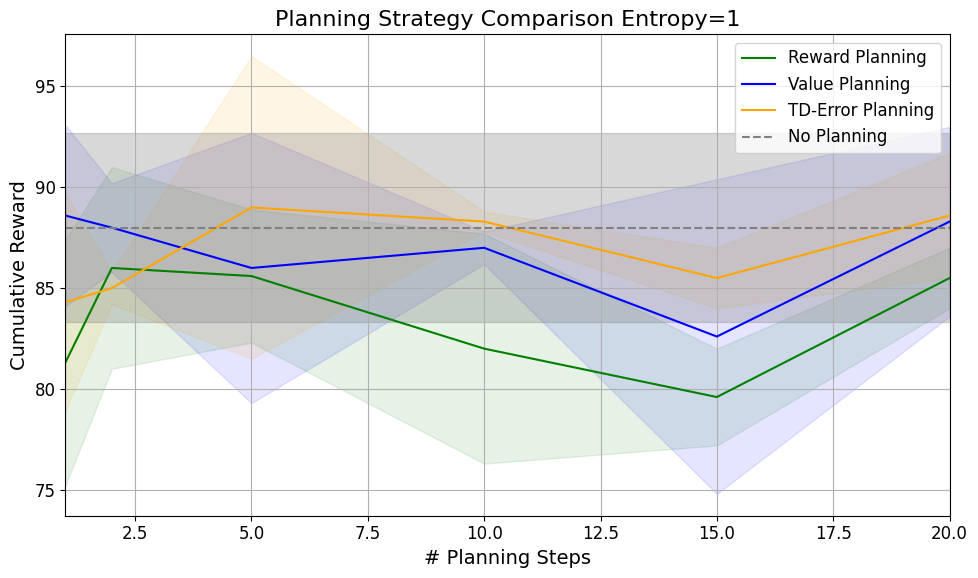

In [12]:
# Load the CSV
df = pd.read_csv("entropy_1_comparison.csv")

# Use exact column names from your CSV
steps = df["Num. Planning Steps"].values
mask = steps > 0

# Start the plot
plt.figure(figsize=(10, 6))

# Reward Planning
plt.plot(steps[mask], df["Reward Planning Mean"][mask], label="Reward Planning", color="green")
plt.fill_between(steps[mask],
                 df["Reward Planning Mean"][mask] - df["Reward Planning Std"][mask],
                 df["Reward Planning Mean"][mask] + df["Reward Planning Std"][mask],
                 alpha=0.1, color="green")

# Value Planning
plt.plot(steps[mask], df["Value Planning Mean"][mask], label="Value Planning", color="blue")
plt.fill_between(steps[mask],
                 df["Value Planning Mean"][mask] - df["Value Planning Std"][mask],
                 df["Value Planning Mean"][mask] + df["Value Planning Std"][mask],
                 alpha=0.1, color="blue")

# TD-Error Planning
plt.plot(steps[mask], df["TD-Error Planning Mean"][mask], label="TD-Error Planning", color="orange")
plt.fill_between(steps[mask],
                 df["TD-Error Planning Mean"][mask] - df["TD-Error Planning Std"][mask],
                 df["TD-Error Planning Mean"][mask] + df["TD-Error Planning Std"][mask],
                 alpha=0.1, color="orange")

# No-planning baseline (Steps == 0)
base_reward = df.loc[df["Num. Planning Steps"] == 0, "Reward Planning Mean"].values[0]
base_std = df.loc[df["Num. Planning Steps"] == 0, "Reward Planning Std"].values[0]
plt.axhline(y=base_reward, linestyle='--', color='gray', label='No Planning')
plt.fill_between(steps[mask], base_reward - base_std, base_reward + base_std, color='gray', alpha=0.3)

plt.xlim(1, 20)
plt.xlabel("# Planning Steps")
plt.ylabel("Cumulative Reward")
plt.title("Planning Strategy Comparison Entropy=1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()